# Logistic Regression Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

from preprocessing_utils_fixed import (
    load_and_prepare_data_fixed,
    create_preprocessing_pipeline,
    evaluate_with_cross_validation,
    print_evaluation_metrics_fixed
)

## Load and Prepare Data

In [2]:
print("\n" + "="*80)
print("LOGISTIC REGRESSION MODEL")
print("="*80)

X_train, X_test, y_train, y_test, feature_names = \
    load_and_prepare_data_fixed(
        test_size=0.3, 
        random_state=42, 
        exclude_diagnostic_features=True 
    )

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {len(feature_names)}")


LOGISTIC REGRESSION MODEL
FIXED DATA PREPROCESSING (NO DATA LEAKAGE)

[1] Loading dataset from: Dataset/diana_dataset_imputed.csv
    Dataset shape: (1376, 20)

[2] Creating binary target variable
    Class 0 (Non-Diabetic): 1170 (85.03%)
    Class 1 (Diabetic): 206 (14.97%)

[3] EXCLUDING HbA1c and FBS (diagnostic criteria - cause data leakage)
    Using 11 features (no diagnostic markers)
     1. age
     2. bmi
     3. hdl
     4. triglycerides
     5. total_cholesterol
     6. systolic
     7. diastolic
     8. ldl
     9. smoking_status
    10. physical_activity
    11. alcohol_use

[4] Splitting data BEFORE preprocessing (prevents leakage)
    Training set: 963 samples
    Testing set: 413 samples
    Training - Diabetic: 144 (14.95%)
    Testing - Diabetic: 62 (15.01%)

[5] Returning RAW data (preprocessing will be done in Pipeline)
    - This ensures scaler and encoders are fit ONLY on training data
    - Prevents test set information from leaking into training


Training samp

## Correlation Matrix Analysis

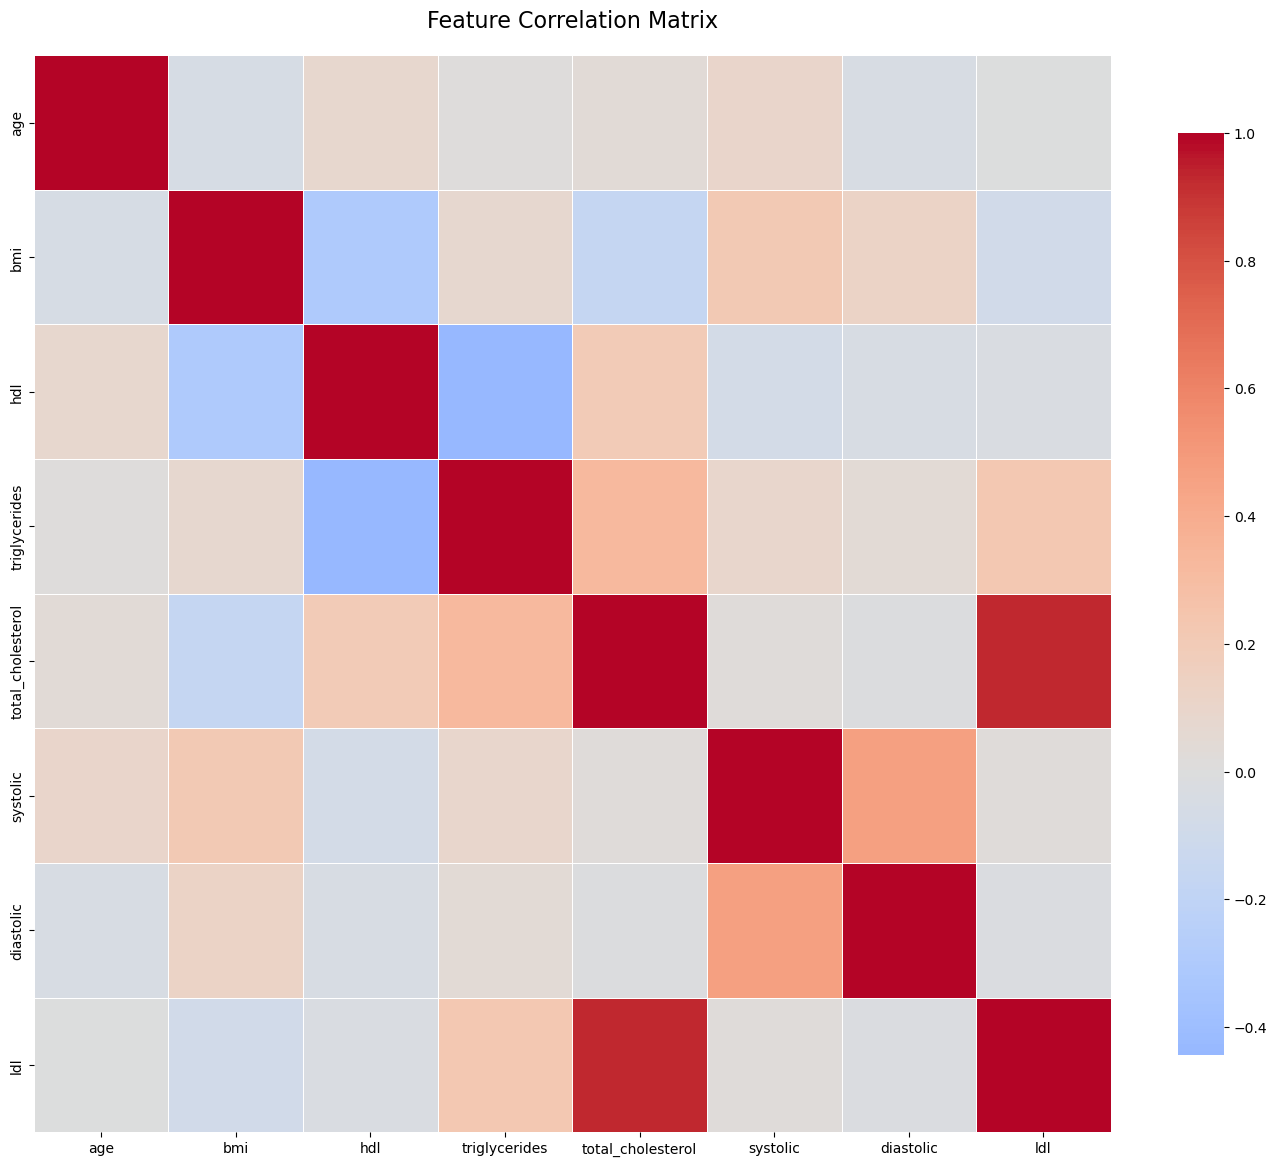


Highly Correlated Feature Pairs (|correlation| > 0.7):
total_cholesterol              <-> ldl                           :  0.932


In [3]:
# Select only numerical features for correlation matrix
numerical_features = X_train.select_dtypes(include=[np.number])

# Calculate correlation matrix
correlation_matrix = numerical_features.corr()

# Create figure
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Show highly correlated features
print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
print("="*60)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"{correlation_matrix.columns[i]:30s} <-> {correlation_matrix.columns[j]:30s}: {correlation_matrix.iloc[i, j]:6.3f}")

## Create Preprocessing Pipeline

In [4]:
preprocessor = create_preprocessing_pipeline(X_train, feature_names)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=0.1,  
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

print("Preprocessing pipeline created successfully!")


[PIPELINE SETUP]
  Categorical features (3): ['smoking_status', 'physical_activity', 'alcohol_use']
  Numerical features (8): ['age', 'bmi', 'hdl', 'triglycerides', 'total_cholesterol', 'systolic', 'diastolic', 'ldl']
Preprocessing pipeline created successfully!


## Cross-Validation

In [5]:
print("\n" + "="*80)
print("CROSS-VALIDATION (Checks for overfitting)")
print("="*80)

cv_results = evaluate_with_cross_validation(model, X_train, y_train, cv=5)


CROSS-VALIDATION (Checks for overfitting)

[CROSS-VALIDATION] Using 5-Fold Stratified CV
  Accuracy    : 0.6874 (+/- 0.0417)
  Precision   : 0.2872 (+/- 0.0347)
  Recall      : 0.7155 (+/- 0.0386)
  F1          : 0.4088 (+/- 0.0377)
  Roc_auc     : 0.7545 (+/- 0.0358)


## Train Model

In [6]:
print("\n" + "="*80)
print("TRAINING ON FULL TRAINING SET")
print("="*80)
print(f"\n[1] Training model on {len(X_train)} samples")

model.fit(X_train, y_train)
print("    Training complete!")


TRAINING ON FULL TRAINING SET

[1] Training model on 963 samples
    Training complete!


## Feature Importance


[2] Extracting feature importance

    Top 10 Most Important Features:
    + num__bmi                      :   0.4906
    - cat__alcohol_use_Moderate     :  -0.4381
    + cat__alcohol_use_Light        :   0.4188
    + num__systolic                 :   0.4128
    + num__triglycerides            :   0.3599
    - num__hdl                      :  -0.3442
    - num__ldl                      :  -0.2312
    - num__total_cholesterol        :  -0.1865
    - cat__smoking_status_Never     :  -0.1621
    - cat__smoking_status_Former    :  -0.1412


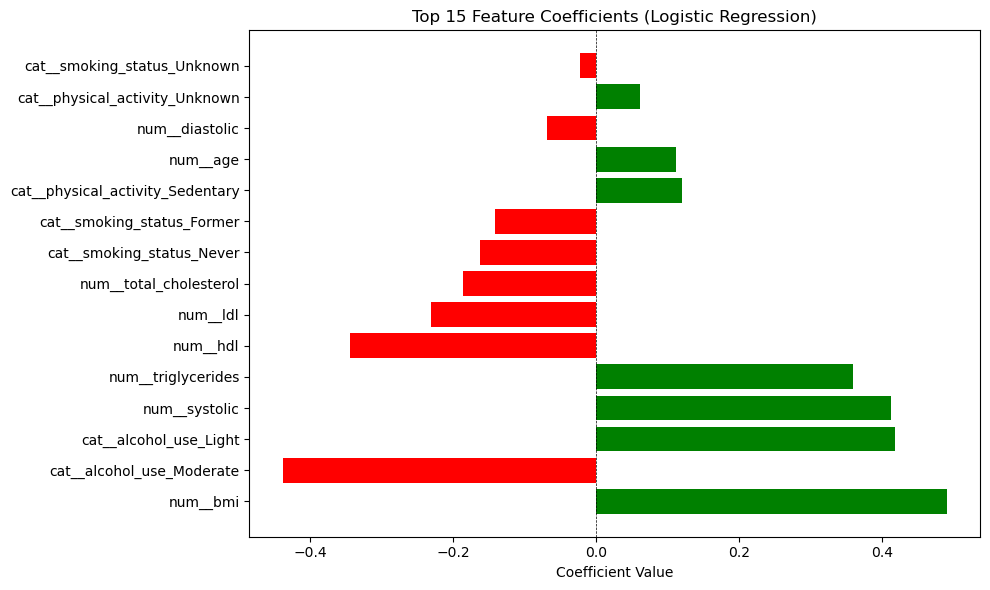

In [7]:
print("\n[2] Extracting feature importance")

try:
    feature_names_out = model.named_steps['preprocessor'].get_feature_names_out()
except:
    numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
    feature_names_out = numerical_features + [f"{cat}_encoded" for cat in categorical_features]

coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Coefficient': coefficients
})
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("\n    Top 10 Most Important Features:")
for idx, row in coef_df.head(10).iterrows():
    sign = "+" if row['Coefficient'] > 0 else "-"
    print(f"    {sign} {row['Feature']:30s}: {row['Coefficient']:8.4f}")

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = coef_df.head(15)
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients (Logistic Regression)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## Make Predictions and Evaluate

In [8]:
print("\n[3] Making predictions")
y_train_pred = model.predict(X_train)
y_train_pred_proba = model.predict_proba(X_train)[:, 1]

y_test_pred = model.predict(X_test)
y_test_pred_proba = model.predict_proba(X_test)[:, 1]
print("   Predictions complete!")

train_metrics = print_evaluation_metrics_fixed(
    y_train, y_train_pred, y_train_pred_proba,
    "Logistic Regression - Training Set"
)

test_metrics = print_evaluation_metrics_fixed(
    y_test, y_test_pred, y_test_pred_proba,
    "Logistic Regression - Test Set"
)


[3] Making predictions
   Predictions complete!

EVALUATION RESULTS - Logistic Regression - Training Set

[PERFORMANCE METRICS]
  Accuracy:  0.6937 (69.37%)
  Precision: 0.2932 (29.32%)
  Recall:    0.7431 (74.31%)
  F1-Score:  0.4204
  ROC-AUC:   0.7745

[CONFUSION MATRIX]
                Predicted
              Neg    Pos
  Actual Neg   561    258
         Pos    37    107

[ADDITIONAL METRICS]
  True Positives:  107
  True Negatives:  561
  False Positives: 258
  False Negatives: 37
  Specificity:     0.6850
  NPV:             0.9381

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

Non-Diabetic       0.94      0.68      0.79       819
    Diabetic       0.29      0.74      0.42       144

    accuracy                           0.69       963
   macro avg       0.62      0.71      0.61       963
weighted avg       0.84      0.69      0.74       963


EVALUATION RESULTS - Logistic Regression - Test Set

[PERFORMANCE METRICS]
  Accuracy:  0.6998 (69.98%)

## Cross-Validation vs Test Set Comparison

In [9]:
print("\n" + "="*80)
print("CROSS-VALIDATION vs TEST SET COMPARISON")
print("="*80)
print(f"\n{'Metric':<12} {'CV Mean':<12} {'CV Std':<12} {'Test Set':<12} {'Match?':<12}")
print("-"*80)

metric_mapping = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1_score',
    'roc_auc': 'roc_auc'
}

for cv_metric, test_metric in metric_mapping.items():
    cv_mean = cv_results[cv_metric]['mean']
    cv_std = cv_results[cv_metric]['std']
    test_val = test_metrics[test_metric]
    match = "Good" if abs(cv_mean - test_val) < 2*cv_std else "Check"
    
    print(f"{cv_metric:<12} {cv_mean:>11.4f} {cv_std:>11.4f} {test_val:>11.4f} {match:<12}")

print("\n[INTERPRETATION]")
if cv_results['accuracy']['mean'] < 0.85:
    print("  Performance is realistic for medical prediction without diagnostic markers.")
else:
    print("  Performance is good but check for any remaining leakage.")

print("\n" + "="*80)
print("MODEL TRAINING COMPLETE!")
print("="*80)


CROSS-VALIDATION vs TEST SET COMPARISON

Metric       CV Mean      CV Std       Test Set     Match?      
--------------------------------------------------------------------------------
accuracy          0.6874      0.0417      0.6998 Good        
precision         0.2872      0.0347      0.3086 Good        
recall            0.7155      0.0386      0.8065 Check       
f1                0.4088      0.0377      0.4464 Good        
roc_auc           0.7545      0.0358      0.8237 Good        

[INTERPRETATION]
  Performance is realistic for medical prediction without diagnostic markers.

MODEL TRAINING COMPLETE!
